In [86]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [196]:
#Carga desde un archivo .xlsx sin indice
df= pd.read_csv('Leads_Reales_sin_valores_atipicos.csv') 

In [88]:
#Verificamos información del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            29 non-null     int64  
 1   Mes                   29 non-null     str    
 2   Año                   29 non-null     float64
 3   Total                 29 non-null     float64
 4   Ilocalizable          29 non-null     int64  
 5   No Contesta           29 non-null     int64  
 6   D. Incorrectos        29 non-null     int64  
 7   Duplicados            29 non-null     float64
 8   Efectivos             29 non-null     float64
 9   Abiertos              29 non-null     int64  
 10  Ventas                29 non-null     int64  
 11  Conversion            29 non-null     float64
 12  Efectividad de Leads  29 non-null     float64
dtypes: float64(6), int64(6), str(1)
memory usage: 3.1 KB


**Determinación de Clases para datos agrupados**


In [89]:
# Ajustar maximo de filas
pd.options.display.max_rows = None

In [90]:
#Corroboramos valores nulos
valores_nulos=df.isnull().sum()
valores_nulos

Unnamed: 0              0
Mes                     0
Año                     0
Total                   0
Ilocalizable            0
No Contesta             0
D. Incorrectos          0
Duplicados              0
Efectivos               0
Abiertos                0
Ventas                  0
Conversion              0
Efectividad de Leads    0
dtype: int64

In [91]:
#Calculamos el numero total de la población "n"
df['Total']. info()
n=29

<class 'pandas.Series'>
RangeIndex: 29 entries, 0 to 28
Series name: Total
Non-Null Count  Dtype  
--------------  -----  
29 non-null     float64
dtypes: float64(1)
memory usage: 364.0 bytes


In [92]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max=df['Total'].max()
Min=df['Total'].min()
Limites= [Min, Max]
Limites

[np.float64(0.0), np.float64(1973.0)]

In [93]:
#Calculamos el rango R
R=Max-Min
R

np.float64(1973.0)

In [94]:
#Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni= 1+3.32*np.log10(n)
ni

np.float64(5.855161353024534)

In [95]:
#Calculamos el Ancho del Intervalo "i"
i=R/ni
i

np.float64(336.96765657548104)

**Creación de Categorias a partir de clases**

In [153]:
#Categorización de variables
#Declaramos 8 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos=np.linspace(-0.1, 1973.01, 6)
intervalos

array([-1.000000e-01,  3.945220e+02,  7.891440e+02,  1.183766e+03,
        1.578388e+03,  1.973010e+03])

In [154]:
#Creamos las categorías 
categorias= ["Categoría1(-1.000000e-01-3.945220e+02)", "Categoría2(3.945220e+02+02-7.891440e+02)", "Categoría3(7.891440e+02-1.183766e+03)", "Categoría4(1.183766e+03-1.578388e+03)", "Categoría5(1.578388e+03-1.973010e+03)"]

In [157]:
#Finalmente creamos las categorías en la columna numérica
df['Total']=pd.cut(x= df['Total'], bins=intervalos, labels= categorias)
df['Total']

0       Categoría1(-1.000000e-01-3.945220e+02)
1     Categoría2(3.945220e+02+02-7.891440e+02)
2       Categoría1(-1.000000e-01-3.945220e+02)
3     Categoría2(3.945220e+02+02-7.891440e+02)
4     Categoría2(3.945220e+02+02-7.891440e+02)
5        Categoría3(7.891440e+02-1.183766e+03)
6        Categoría3(7.891440e+02-1.183766e+03)
7        Categoría4(1.183766e+03-1.578388e+03)
8        Categoría4(1.183766e+03-1.578388e+03)
9        Categoría5(1.578388e+03-1.973010e+03)
10       Categoría4(1.183766e+03-1.578388e+03)
11       Categoría4(1.183766e+03-1.578388e+03)
12       Categoría3(7.891440e+02-1.183766e+03)
13    Categoría2(3.945220e+02+02-7.891440e+02)
14       Categoría3(7.891440e+02-1.183766e+03)
15       Categoría3(7.891440e+02-1.183766e+03)
16       Categoría3(7.891440e+02-1.183766e+03)
17       Categoría3(7.891440e+02-1.183766e+03)
18       Categoría4(1.183766e+03-1.578388e+03)
19       Categoría4(1.183766e+03-1.578388e+03)
20       Categoría3(7.891440e+02-1.183766e+03)
21       Cate

In [158]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = df['Total'].value_counts().reset_index()
Tabla_freq

,Total,count
0,Categoría4(1.183766e+03-1.578388e+03),12
1,Categoría3(7.891440e+02-1.183766e+03),9
2,Categoría2(3.945220e+02+02-7.891440e+02),4
3,Categoría1(-1.000000e-01-3.945220e+02),2
4,Categoría5(1.578388e+03-1.973010e+03),2


In [159]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>0]
Filtro

,Total,count
0,Categoría4(1.183766e+03-1.578388e+03),12
1,Categoría3(7.891440e+02-1.183766e+03),9
2,Categoría2(3.945220e+02+02-7.891440e+02),4
3,Categoría1(-1.000000e-01-3.945220e+02),2
4,Categoría5(1.578388e+03-1.973010e+03),2


In [160]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('Total')
Filtro_index

,count
Total,
Categoría4(1.183766e+03-1.578388e+03),12
Categoría3(7.891440e+02-1.183766e+03),9
Categoría2(3.945220e+02+02-7.891440e+02),4
Categoría1(-1.000000e-01-3.945220e+02),2
Categoría5(1.578388e+03-1.973010e+03),2


Text(0, 0.5, 'Frecuencia')

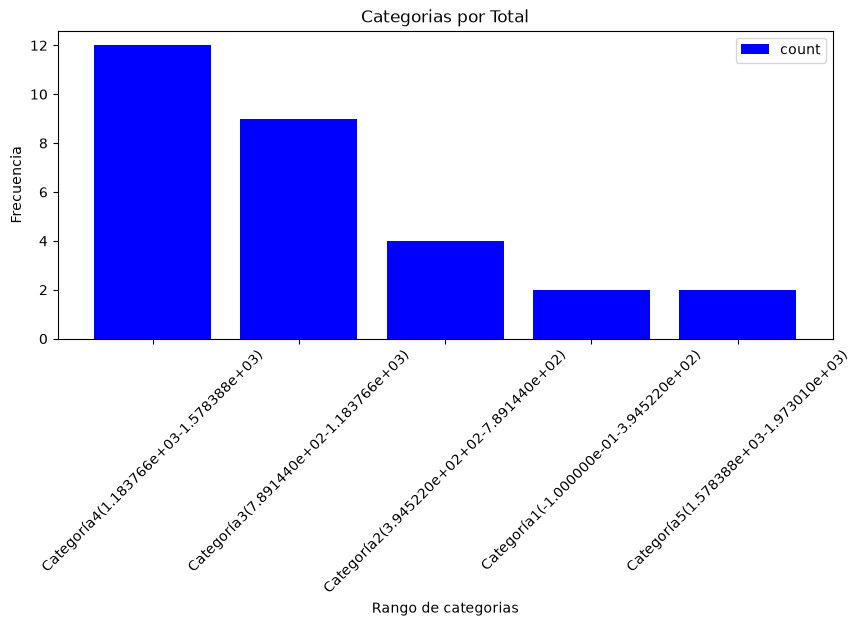

In [161]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "blue", rot=45)
plt.title('Categorias por Total')
plt.xlabel('Rango de categorias')
plt.ylabel('Frecuencia')

**Ilocalizable**

In [120]:
#Calculamos el numero total de la población "n"
df['Ilocalizable']. info()
n=29

<class 'pandas.Series'>
RangeIndex: 29 entries, 0 to 28
Series name: Ilocalizable
Non-Null Count  Dtype
--------------  -----
29 non-null     int64
dtypes: int64(1)
memory usage: 364.0 bytes


In [103]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max=df['Ilocalizable'].max()
Min=df['Ilocalizable'].min()
Limites= [Min, Max]
Limites

[np.int64(0), np.int64(514)]

In [104]:
#Calculamos el rango R
R=Max-Min
R

np.int64(514)

In [105]:
#Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni= 1+3.32*np.log10(n)
ni

np.float64(5.855161353024534)

In [106]:
#Calculamos el Ancho del Intervalo "i"
i=R/ni
i

np.float64(87.78579598570565)

**Creación de Categorias**

In [173]:
#Categorización de variables
#Declaramos 8 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos=np.linspace(-0.01, 514.01, 6)
intervalos

array([-1.00000e-02,  1.02794e+02,  2.05598e+02,  3.08402e+02,
        4.11206e+02,  5.14010e+02])

In [174]:
#Creamos las categorías 
categorias= ["Categoría1(-1.00000e-02- 1.02794e+02)", "Categoría2( 1.02794e+02- 2.05598e+02)","Categoría3(2.05598e+02- 3.08402e+02)", "Categoría4( 3.08402e+02- 4.11208e+02)",
             "Categoría5(4.11208e+02-5.14010e+02)"]

In [177]:
#Finalmente creamos las categorías en la columna numérica
df['Ilocalizable']=pd.cut(x= df['Ilocalizable'], bins=intervalos, labels= categorias)
df['Ilocalizable']

0     Categoría1(-1.00000e-02- 1.02794e+02)
1     Categoría2( 1.02794e+02- 2.05598e+02)
2     Categoría1(-1.00000e-02- 1.02794e+02)
3     Categoría1(-1.00000e-02- 1.02794e+02)
4     Categoría1(-1.00000e-02- 1.02794e+02)
5     Categoría2( 1.02794e+02- 2.05598e+02)
6     Categoría2( 1.02794e+02- 2.05598e+02)
7       Categoría5(4.11208e+02-5.14010e+02)
8       Categoría5(4.11208e+02-5.14010e+02)
9       Categoría5(4.11208e+02-5.14010e+02)
10    Categoría2( 1.02794e+02- 2.05598e+02)
11    Categoría4( 3.08402e+02- 4.11208e+02)
12    Categoría1(-1.00000e-02- 1.02794e+02)
13    Categoría1(-1.00000e-02- 1.02794e+02)
14    Categoría1(-1.00000e-02- 1.02794e+02)
15    Categoría1(-1.00000e-02- 1.02794e+02)
16    Categoría1(-1.00000e-02- 1.02794e+02)
17    Categoría1(-1.00000e-02- 1.02794e+02)
18    Categoría2( 1.02794e+02- 2.05598e+02)
19    Categoría1(-1.00000e-02- 1.02794e+02)
20    Categoría1(-1.00000e-02- 1.02794e+02)
21    Categoría1(-1.00000e-02- 1.02794e+02)
22    Categoría1(-1.00000e-02- 1

In [178]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = df['Ilocalizable'].value_counts().reset_index()
Tabla_freq

,Ilocalizable,count
0,Categoría1(-1.00000e-02- 1.02794e+02),14
1,Categoría2( 1.02794e+02- 2.05598e+02),9
2,Categoría5(4.11208e+02-5.14010e+02),3
3,Categoría3(2.05598e+02- 3.08402e+02),2
4,Categoría4( 3.08402e+02- 4.11208e+02),1


In [179]:
#Ajusto el indice de mi dataframe
Filtro_index= Tabla_freq.set_index('Ilocalizable')
Filtro_index

,count
Ilocalizable,
Categoría1(-1.00000e-02- 1.02794e+02),14
Categoría2( 1.02794e+02- 2.05598e+02),9
Categoría5(4.11208e+02-5.14010e+02),3
Categoría3(2.05598e+02- 3.08402e+02),2
Categoría4( 3.08402e+02- 4.11208e+02),1


Text(0, 0.5, 'Frecuencia')

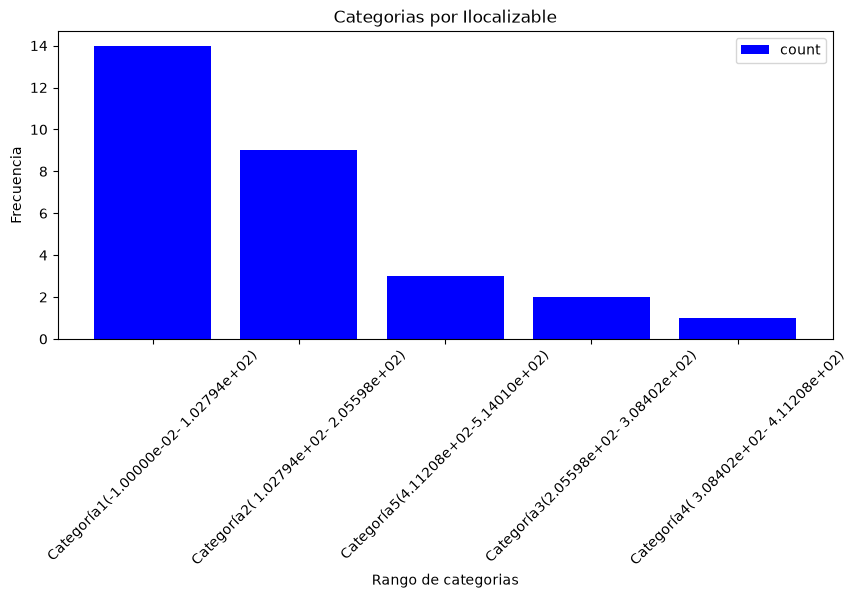

In [180]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "blue", rot=45)
plt.title('Categorias por Ilocalizable')
plt.xlabel('Rango de categorias')
plt.ylabel('Frecuencia')

**No Contesta**

In [126]:
#Calculamos el numero total de la población "n"
df['No Contesta']. info()
n=29

<class 'pandas.Series'>
RangeIndex: 29 entries, 0 to 28
Series name: No Contesta
Non-Null Count  Dtype
--------------  -----
29 non-null     int64
dtypes: int64(1)
memory usage: 364.0 bytes


In [65]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max=df['No Contesta'].max()
Min=df['No Contesta'].min()
Limites= [Min, Max]
Limites

[np.int64(0), np.int64(606)]

In [66]:
#Calculamos el rango R
R=Max-Min
R

np.int64(606)

In [67]:
#Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni= 1+3.32*np.log10(n)
ni

np.float64(5.855161353024534)

In [68]:
#Calculamos el Ancho del Intervalo "i"
i=R/ni
i

np.float64(103.49842873022884)

In [127]:
#Categorización de variables
#Declaramos 8 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos=np.linspace(-0.01, 606.01, 6)
intervalos

array([-1.00000e-02,  1.21194e+02,  2.42398e+02,  3.63602e+02,
        4.84806e+02,  6.06010e+02])

In [182]:
#Creamos las categorías 
categorias= ["Categoría1(-1.00000e-02- 1.21194e+02)", "Categoría2( 1.21194e+02- 2.42398e+02)","Categoría3(2.42398e+02- 3.63602e+02)", "Categoría4( 3.63602e+02- 4.84806e+02)",
             "Categoría5(4.84806e+02-6.06010e+02)"]

In [185]:
#Finalmente creamos las categorías en la columna numérica
df['No Contesta']=pd.cut(x= df['No Contesta'], bins=intervalos, labels= categorias)
df['No Contesta']

0     Categoría1(-1.00000e-02- 1.21194e+02)
1     Categoría1(-1.00000e-02- 1.21194e+02)
2     Categoría1(-1.00000e-02- 1.21194e+02)
3     Categoría1(-1.00000e-02- 1.21194e+02)
4     Categoría1(-1.00000e-02- 1.21194e+02)
5     Categoría2( 1.21194e+02- 2.42398e+02)
6      Categoría3(2.42398e+02- 3.63602e+02)
7     Categoría4( 3.63602e+02- 4.84806e+02)
8     Categoría4( 3.63602e+02- 4.84806e+02)
9                                       NaN
10    Categoría4( 3.63602e+02- 4.84806e+02)
11    Categoría2( 1.21194e+02- 2.42398e+02)
12    Categoría2( 1.21194e+02- 2.42398e+02)
13    Categoría1(-1.00000e-02- 1.21194e+02)
14    Categoría1(-1.00000e-02- 1.21194e+02)
15    Categoría2( 1.21194e+02- 2.42398e+02)
16    Categoría1(-1.00000e-02- 1.21194e+02)
17     Categoría3(2.42398e+02- 3.63602e+02)
18     Categoría3(2.42398e+02- 3.63602e+02)
19                                      NaN
20    Categoría4( 3.63602e+02- 4.84806e+02)
21      Categoría5(4.84806e+02-6.06010e+02)
22     Categoría3(2.42398e+02- 3

In [186]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = df['No Contesta'].value_counts().reset_index()
Tabla_freq

,No Contesta,count
0,Categoría2( 1.21194e+02- 2.42398e+02),10
1,Categoría1(-1.00000e-02- 1.21194e+02),8
2,Categoría3(2.42398e+02- 3.63602e+02),4
3,Categoría4( 3.63602e+02- 4.84806e+02),4
4,Categoría5(4.84806e+02-6.06010e+02),1


In [187]:
#Ajusto el indice de mi dataframe
Filtro_index= Tabla_freq.set_index('No Contesta')
Filtro_index

,count
No Contesta,
Categoría2( 1.21194e+02- 2.42398e+02),10
Categoría1(-1.00000e-02- 1.21194e+02),8
Categoría3(2.42398e+02- 3.63602e+02),4
Categoría4( 3.63602e+02- 4.84806e+02),4
Categoría5(4.84806e+02-6.06010e+02),1


Text(0, 0.5, 'Frecuencia')

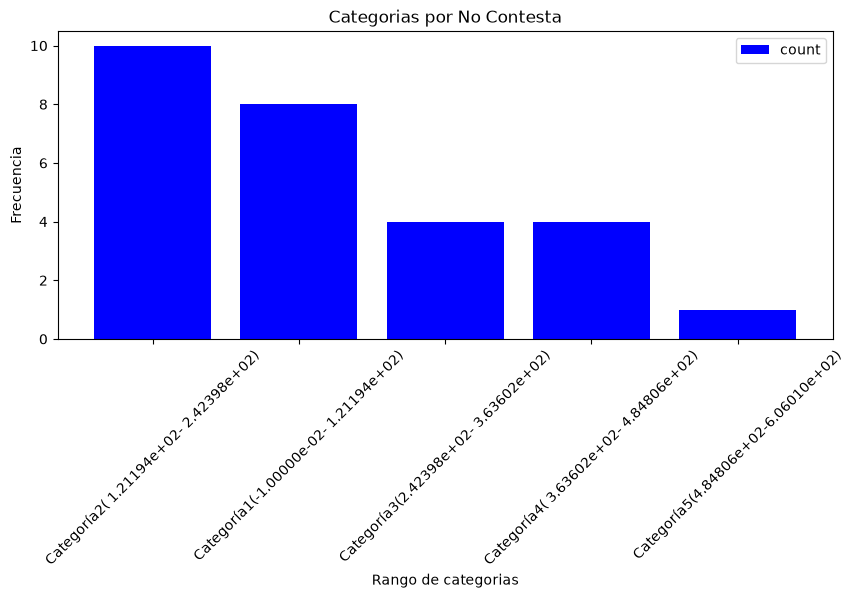

In [188]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "blue", rot=45)
plt.title('Categorias por No Contesta')
plt.xlabel('Rango de categorias')
plt.ylabel('Frecuencia')

**D.Incorrectos**

In [75]:
#Calculamos el numero total de la población "n"
df['D. Incorrectos']. info()
n=29

<class 'pandas.Series'>
RangeIndex: 29 entries, 0 to 28
Series name: D. Incorrectos
Non-Null Count  Dtype
--------------  -----
29 non-null     int64
dtypes: int64(1)
memory usage: 364.0 bytes


In [76]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max=df['D. Incorrectos'].max()
Min=df['D. Incorrectos'].min()
Limites= [Min, Max]
Limites

[np.int64(0), np.int64(62)]

In [77]:
#Calculamos el rango R
R=Max-Min
R

np.int64(62)

In [78]:
#Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni= 1+3.32*np.log10(n)
ni

np.float64(5.855161353024534)

In [79]:
#Calculamos el Ancho del Intervalo "i"
i=R/ni
i

np.float64(10.588948153917803)

In [193]:
#Categorización de variables
#Declaramos 8 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos=np.linspace(-0.01, 62.01, 6)
intervalos

array([-1.0000e-02,  1.2394e+01,  2.4798e+01,  3.7202e+01,  4.9606e+01,
        6.2010e+01])

In [194]:
#Creamos las categorías 
categorias= ["Categoría1(-1.0000e-02- 1.2394e+01)", "Categoría2( 1.2394e+01- 2.4798e+01)","Categoría3(2.4798e+01-  3.7202e+01)", "Categoría4(  3.7202e+01- 4.9606e+01)",
             "Categoría5(4.9606e+01-6.2010ee+01)"]

In [197]:
#Finalmente creamos las categorías en la columna numérica
df['D. Incorrectos']=pd.cut(x= df['D. Incorrectos'], bins=intervalos, labels= categorias)
df['D. Incorrectos']

0      Categoría1(-1.0000e-02- 1.2394e+01)
1      Categoría1(-1.0000e-02- 1.2394e+01)
2      Categoría1(-1.0000e-02- 1.2394e+01)
3      Categoría1(-1.0000e-02- 1.2394e+01)
4      Categoría2( 1.2394e+01- 2.4798e+01)
5      Categoría3(2.4798e+01-  3.7202e+01)
6      Categoría1(-1.0000e-02- 1.2394e+01)
7      Categoría2( 1.2394e+01- 2.4798e+01)
8      Categoría2( 1.2394e+01- 2.4798e+01)
9      Categoría2( 1.2394e+01- 2.4798e+01)
10    Categoría4(  3.7202e+01- 4.9606e+01)
11      Categoría5(4.9606e+01-6.2010ee+01)
12      Categoría5(4.9606e+01-6.2010ee+01)
13     Categoría2( 1.2394e+01- 2.4798e+01)
14     Categoría1(-1.0000e-02- 1.2394e+01)
15     Categoría1(-1.0000e-02- 1.2394e+01)
16     Categoría1(-1.0000e-02- 1.2394e+01)
17     Categoría1(-1.0000e-02- 1.2394e+01)
18     Categoría1(-1.0000e-02- 1.2394e+01)
19     Categoría1(-1.0000e-02- 1.2394e+01)
20     Categoría1(-1.0000e-02- 1.2394e+01)
21     Categoría1(-1.0000e-02- 1.2394e+01)
22     Categoría1(-1.0000e-02- 1.2394e+01)
23     Cate

In [198]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = df['D. Incorrectos'].value_counts().reset_index()
Tabla_freq

,D. Incorrectos,count
0,Categoría1(-1.0000e-02- 1.2394e+01),15
1,Categoría2( 1.2394e+01- 2.4798e+01),5
2,Categoría3(2.4798e+01- 3.7202e+01),3
3,Categoría4( 3.7202e+01- 4.9606e+01),3
4,Categoría5(4.9606e+01-6.2010ee+01),3


In [199]:
#Ajusto el indice de mi dataframe
Filtro_index= Tabla_freq.set_index('D. Incorrectos')
Filtro_index

,count
D. Incorrectos,
Categoría1(-1.0000e-02- 1.2394e+01),15
Categoría2( 1.2394e+01- 2.4798e+01),5
Categoría3(2.4798e+01- 3.7202e+01),3
Categoría4( 3.7202e+01- 4.9606e+01),3
Categoría5(4.9606e+01-6.2010ee+01),3


Text(0, 0.5, 'Frecuencia')

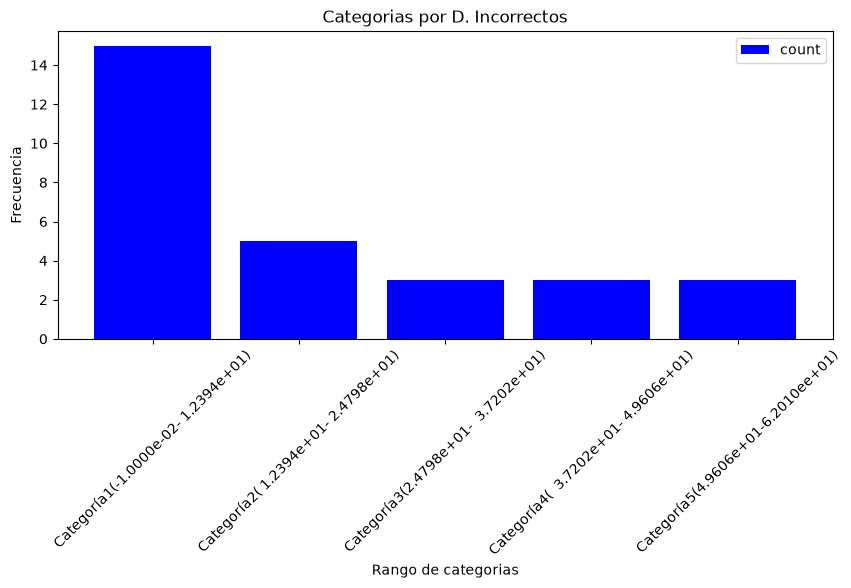

In [201]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "blue", rot=45)
plt.title('Categorias por D. Incorrectos')
plt.xlabel('Rango de categorias')
plt.ylabel('Frecuencia')

**Duplicados**

In [202]:
#Calculamos el numero total de la población "n"
df['Duplicados']. info()
n=29

<class 'pandas.Series'>
RangeIndex: 29 entries, 0 to 28
Series name: Duplicados
Non-Null Count  Dtype  
--------------  -----  
29 non-null     float64
dtypes: float64(1)
memory usage: 364.0 bytes


In [203]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max=df['Duplicados'].max()
Min=df['Duplicados'].min()
Limites= [Min, Max]
Limites

[np.float64(0.0), np.float64(93.0)]

In [204]:
#Calculamos el rango R
R=Max-Min
R

np.float64(93.0)

In [205]:
#Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni= 1+3.32*np.log10(n)
ni

np.float64(5.855161353024534)

In [206]:
#Calculamos el Ancho del Intervalo "i"
i=R/ni
i

np.float64(15.883422230876704)

In [207]:
#Categorización de variables
#Declaramos 8 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos=np.linspace(-0.01, 93.01, 6)
intervalos

array([-1.0000e-02,  1.8594e+01,  3.7198e+01,  5.5802e+01,  7.4406e+01,
        9.3010e+01])

In [208]:
#Creamos las categorías 
categorias= ["Categoría1(-1.0000e-02- 1.8594e+01)", "Categoría2( 1.8594e+01- 3.7198e+01)","Categoría3(3.7198e+01-5.5802e+01)", "Categoría4(  5.5802e+01- 7.4406e+01)",
             "Categoría5(7.4406e+01-9.3010e+01)"]

In [209]:
#Finalmente creamos las categorías en la columna numérica
df['Duplicados']=pd.cut(x= df['Duplicados'], bins=intervalos, labels= categorias)
df['Duplicados']

0      Categoría1(-1.0000e-02- 1.8594e+01)
1      Categoría1(-1.0000e-02- 1.8594e+01)
2      Categoría1(-1.0000e-02- 1.8594e+01)
3      Categoría1(-1.0000e-02- 1.8594e+01)
4      Categoría1(-1.0000e-02- 1.8594e+01)
5      Categoría1(-1.0000e-02- 1.8594e+01)
6      Categoría1(-1.0000e-02- 1.8594e+01)
7      Categoría1(-1.0000e-02- 1.8594e+01)
8      Categoría2( 1.8594e+01- 3.7198e+01)
9      Categoría1(-1.0000e-02- 1.8594e+01)
10     Categoría1(-1.0000e-02- 1.8594e+01)
11       Categoría3(3.7198e+01-5.5802e+01)
12     Categoría2( 1.8594e+01- 3.7198e+01)
13     Categoría2( 1.8594e+01- 3.7198e+01)
14       Categoría3(3.7198e+01-5.5802e+01)
15       Categoría5(7.4406e+01-9.3010e+01)
16     Categoría1(-1.0000e-02- 1.8594e+01)
17    Categoría4(  5.5802e+01- 7.4406e+01)
18       Categoría5(7.4406e+01-9.3010e+01)
19    Categoría4(  5.5802e+01- 7.4406e+01)
20     Categoría1(-1.0000e-02- 1.8594e+01)
21     Categoría1(-1.0000e-02- 1.8594e+01)
22       Categoría3(3.7198e+01-5.5802e+01)
23       Ca

In [210]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = df['Duplicados'].value_counts().reset_index()
Tabla_freq

,Duplicados,count
0,Categoría1(-1.0000e-02- 1.8594e+01),13
1,Categoría2( 1.8594e+01- 3.7198e+01),7
2,Categoría3(3.7198e+01-5.5802e+01),5
3,Categoría4( 5.5802e+01- 7.4406e+01),2
4,Categoría5(7.4406e+01-9.3010e+01),2


In [211]:
#Ajusto el indice de mi dataframe
Filtro_index= Tabla_freq.set_index('Duplicados')
Filtro_index

,count
Duplicados,
Categoría1(-1.0000e-02- 1.8594e+01),13
Categoría2( 1.8594e+01- 3.7198e+01),7
Categoría3(3.7198e+01-5.5802e+01),5
Categoría4( 5.5802e+01- 7.4406e+01),2
Categoría5(7.4406e+01-9.3010e+01),2


Text(0, 0.5, 'Frecuencia')

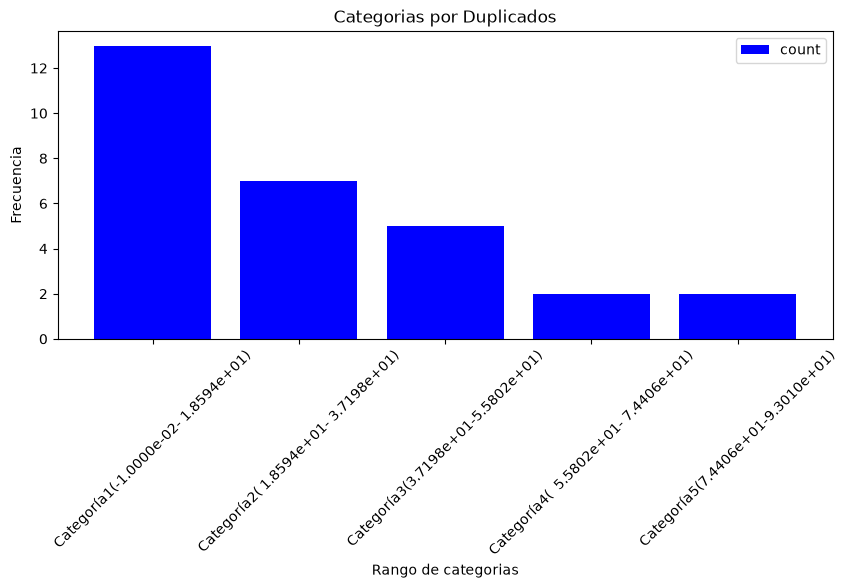

In [212]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "blue", rot=45)
plt.title('Categorias por Duplicados')
plt.xlabel('Rango de categorias')
plt.ylabel('Frecuencia')

**Efectivos**

In [213]:
#Calculamos el numero total de la población "n"
df['Efectivos']. info()
n=29

<class 'pandas.Series'>
RangeIndex: 29 entries, 0 to 28
Series name: Efectivos
Non-Null Count  Dtype  
--------------  -----  
29 non-null     float64
dtypes: float64(1)
memory usage: 364.0 bytes


In [214]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max=df['Efectivos'].max()
Min=df['Efectivos'].min()
Limites= [Min, Max]
Limites

[np.float64(0.0), np.float64(1040.0)]

In [215]:
#Calculamos el rango R
R=Max-Min
R

np.float64(1040.0)

In [216]:
#Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni= 1+3.32*np.log10(n)
ni

np.float64(5.855161353024534)

In [217]:
#Calculamos el Ancho del Intervalo "i"
i=R/ni
i

np.float64(177.62106580765345)

In [218]:
#Categorización de variables
#Declaramos 8 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos=np.linspace(-0.01, 1040.01, 6)
intervalos

array([-1.00000e-02,  2.07994e+02,  4.15998e+02,  6.24002e+02,
        8.32006e+02,  1.04001e+03])

In [219]:
#Creamos las categorías 
categorias= ["Categoría1(1.00000e-02-2.07994e+02)", "Categoría2( 2.07994e+02- 4.15998e+02)","Categoría3(4.15998e+02-6.24002e+02)", "Categoría4(6.24002e+02-8.32006e+02)",
             "Categoría5(8.32006e+02-1.04001e+03)"]

In [220]:
#Finalmente creamos las categorías en la columna numérica
df['Efectivos']=pd.cut(x= df['Efectivos'], bins=intervalos, labels= categorias)
df['Efectivos']

0       Categoría1(1.00000e-02-2.07994e+02)
1     Categoría2( 2.07994e+02- 4.15998e+02)
2       Categoría1(1.00000e-02-2.07994e+02)
3     Categoría2( 2.07994e+02- 4.15998e+02)
4     Categoría2( 2.07994e+02- 4.15998e+02)
5       Categoría3(4.15998e+02-6.24002e+02)
6       Categoría3(4.15998e+02-6.24002e+02)
7       Categoría3(4.15998e+02-6.24002e+02)
8       Categoría3(4.15998e+02-6.24002e+02)
9       Categoría4(6.24002e+02-8.32006e+02)
10      Categoría5(8.32006e+02-1.04001e+03)
11      Categoría5(8.32006e+02-1.04001e+03)
12      Categoría4(6.24002e+02-8.32006e+02)
13      Categoría3(4.15998e+02-6.24002e+02)
14      Categoría4(6.24002e+02-8.32006e+02)
15      Categoría5(8.32006e+02-1.04001e+03)
16      Categoría3(4.15998e+02-6.24002e+02)
17      Categoría4(6.24002e+02-8.32006e+02)
18      Categoría5(8.32006e+02-1.04001e+03)
19      Categoría4(6.24002e+02-8.32006e+02)
20      Categoría4(6.24002e+02-8.32006e+02)
21      Categoría4(6.24002e+02-8.32006e+02)
22      Categoría4(6.24002e+02-8

In [221]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = df['Efectivos'].value_counts().reset_index()
Tabla_freq

,Efectivos,count
0,Categoría4(6.24002e+02-8.32006e+02),13
1,Categoría3(4.15998e+02-6.24002e+02),6
2,Categoría5(8.32006e+02-1.04001e+03),5
3,Categoría2( 2.07994e+02- 4.15998e+02),3
4,Categoría1(1.00000e-02-2.07994e+02),2


In [222]:
#Ajusto el indice de mi dataframe
Filtro_index= Tabla_freq.set_index('Efectivos')
Filtro_index

,count
Efectivos,
Categoría4(6.24002e+02-8.32006e+02),13
Categoría3(4.15998e+02-6.24002e+02),6
Categoría5(8.32006e+02-1.04001e+03),5
Categoría2( 2.07994e+02- 4.15998e+02),3
Categoría1(1.00000e-02-2.07994e+02),2


Text(0, 0.5, 'Frecuencia')

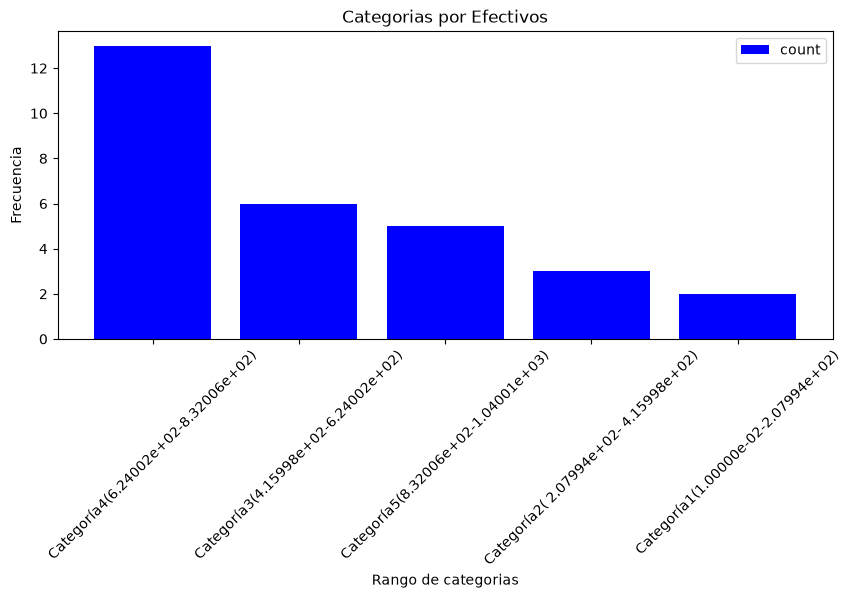

In [223]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "blue", rot=45)
plt.title('Categorias por Efectivos')
plt.xlabel('Rango de categorias')
plt.ylabel('Frecuencia')

**Abiertos**

In [224]:
#Calculamos el numero total de la población "n"
df['Abiertos']. info()
n=29

<class 'pandas.Series'>
RangeIndex: 29 entries, 0 to 28
Series name: Abiertos
Non-Null Count  Dtype
--------------  -----
29 non-null     int64
dtypes: int64(1)
memory usage: 364.0 bytes


In [225]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max=df['Abiertos'].max()
Min=df['Abiertos'].min()
Limites= [Min, Max]
Limites

[np.int64(0), np.int64(823)]

In [226]:
#Calculamos el rango R
R=Max-Min
R

np.int64(823)

In [227]:
#Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni= 1+3.32*np.log10(n)
ni

np.float64(5.855161353024534)

In [228]:
#Calculamos el Ancho del Intervalo "i"
i=R/ni
i

np.float64(140.55974726894115)

In [229]:
#Categorización de variables
#Declaramos 8 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos=np.linspace(-0.01, 823.01, 6)
intervalos

array([-1.00000e-02,  1.64594e+02,  3.29198e+02,  4.93802e+02,
        6.58406e+02,  8.23010e+02])

In [230]:
#Creamos las categorías 
categorias= ["Categoría1(1.00000e-02-1.64594e+02)", "Categoría2( 1.64594e+02-3.29198e+02)","Categoría3(3.29198e+02-4.93802e+02)", "Categoría4(4.93802e+02-6.58406e+02)",
             "Categoría5(6.58406e+02-8.23010e+02)"]

In [231]:
#Finalmente creamos las categorías en la columna numérica
df['Abiertos']=pd.cut(x= df['Abiertos'], bins=intervalos, labels= categorias)
df['Abiertos']

0      Categoría1(1.00000e-02-1.64594e+02)
1      Categoría1(1.00000e-02-1.64594e+02)
2      Categoría1(1.00000e-02-1.64594e+02)
3      Categoría1(1.00000e-02-1.64594e+02)
4      Categoría1(1.00000e-02-1.64594e+02)
5      Categoría1(1.00000e-02-1.64594e+02)
6      Categoría1(1.00000e-02-1.64594e+02)
7      Categoría1(1.00000e-02-1.64594e+02)
8      Categoría1(1.00000e-02-1.64594e+02)
9      Categoría1(1.00000e-02-1.64594e+02)
10     Categoría1(1.00000e-02-1.64594e+02)
11     Categoría3(3.29198e+02-4.93802e+02)
12    Categoría2( 1.64594e+02-3.29198e+02)
13     Categoría1(1.00000e-02-1.64594e+02)
14     Categoría1(1.00000e-02-1.64594e+02)
15     Categoría1(1.00000e-02-1.64594e+02)
16    Categoría2( 1.64594e+02-3.29198e+02)
17    Categoría2( 1.64594e+02-3.29198e+02)
18    Categoría2( 1.64594e+02-3.29198e+02)
19     Categoría3(3.29198e+02-4.93802e+02)
20    Categoría2( 1.64594e+02-3.29198e+02)
21    Categoría2( 1.64594e+02-3.29198e+02)
22     Categoría3(3.29198e+02-4.93802e+02)
23     Cate

In [232]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = df['Abiertos'].value_counts().reset_index()
Tabla_freq

,Abiertos,count
0,Categoría1(1.00000e-02-1.64594e+02),14
1,Categoría2( 1.64594e+02-3.29198e+02),6
2,Categoría3(3.29198e+02-4.93802e+02),4
3,Categoría4(4.93802e+02-6.58406e+02),3
4,Categoría5(6.58406e+02-8.23010e+02),2


In [233]:
#Ajusto el indice de mi dataframe
Filtro_index= Tabla_freq.set_index('Abiertos')
Filtro_index

,count
Abiertos,
Categoría1(1.00000e-02-1.64594e+02),14
Categoría2( 1.64594e+02-3.29198e+02),6
Categoría3(3.29198e+02-4.93802e+02),4
Categoría4(4.93802e+02-6.58406e+02),3
Categoría5(6.58406e+02-8.23010e+02),2


Text(0, 0.5, 'Frecuencia')

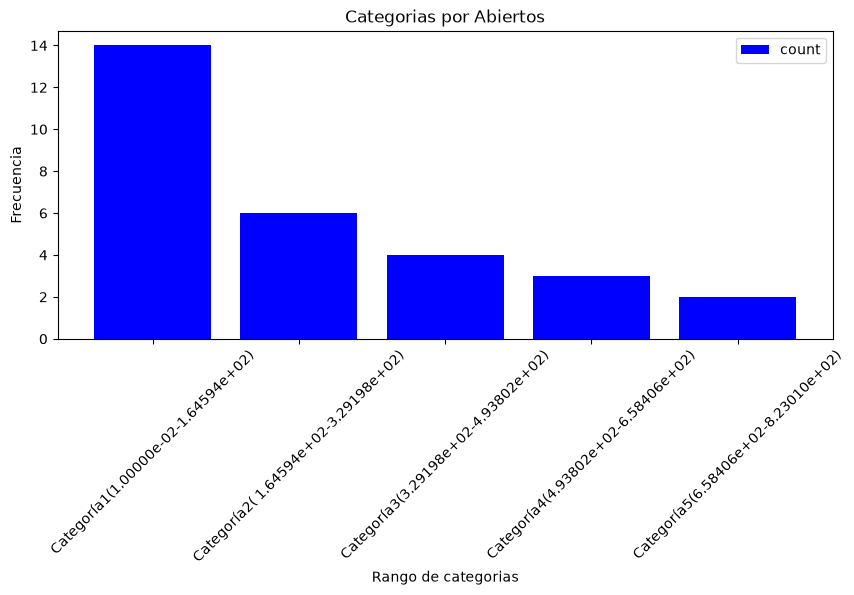

In [234]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "blue", rot=45)
plt.title('Categorias por Abiertos')
plt.xlabel('Rango de categorias')
plt.ylabel('Frecuencia')

**Ventas**

In [235]:
#Calculamos el numero total de la población "n"
df['Ventas']. info()
n=29

<class 'pandas.Series'>
RangeIndex: 29 entries, 0 to 28
Series name: Ventas
Non-Null Count  Dtype
--------------  -----
29 non-null     int64
dtypes: int64(1)
memory usage: 364.0 bytes


In [236]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max=df['Ventas'].max()
Min=df['Ventas'].min()
Limites= [Min, Max]
Limites

[np.int64(0), np.int64(41)]

In [237]:
#Calculamos el rango R
R=Max-Min
R

np.int64(41)

In [238]:
#Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni= 1+3.32*np.log10(n)
ni

np.float64(5.855161353024534)

In [239]:
#Calculamos el Ancho del Intervalo "i"
i=R/ni
i

np.float64(7.002368940494031)

In [240]:
#Categorización de variables
#Declaramos 8 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos=np.linspace(-0.01, 41.01, 6)
intervalos

array([-1.0000e-02,  8.1940e+00,  1.6398e+01,  2.4602e+01,  3.2806e+01,
        4.1010e+01])

In [241]:
#Creamos las categorías 
categorias= ["Categoría1(1.00000e-02-8.1940e+00)", "Categoría2( 8.1940e+00-1.6398e+01)","Categoría3(1.6398e+01-2.4602e+01)", "Categoría4(2.4602e+01-3.2806e+01)",
             "Categoría5(3.2806e+01-4.1010e+01)"]

In [242]:
#Finalmente creamos las categorías en la columna numérica
df['Ventas']=pd.cut(x= df['Ventas'], bins=intervalos, labels= categorias)
df['Ventas']

0     Categoría1(1.00000e-02-8.1940e+00)
1     Categoría2( 8.1940e+00-1.6398e+01)
2     Categoría1(1.00000e-02-8.1940e+00)
3     Categoría1(1.00000e-02-8.1940e+00)
4     Categoría2( 8.1940e+00-1.6398e+01)
5     Categoría1(1.00000e-02-8.1940e+00)
6      Categoría3(1.6398e+01-2.4602e+01)
7      Categoría3(1.6398e+01-2.4602e+01)
8      Categoría3(1.6398e+01-2.4602e+01)
9      Categoría3(1.6398e+01-2.4602e+01)
10     Categoría3(1.6398e+01-2.4602e+01)
11     Categoría4(2.4602e+01-3.2806e+01)
12     Categoría4(2.4602e+01-3.2806e+01)
13     Categoría3(1.6398e+01-2.4602e+01)
14     Categoría4(2.4602e+01-3.2806e+01)
15     Categoría4(2.4602e+01-3.2806e+01)
16     Categoría5(3.2806e+01-4.1010e+01)
17     Categoría5(3.2806e+01-4.1010e+01)
18     Categoría5(3.2806e+01-4.1010e+01)
19     Categoría4(2.4602e+01-3.2806e+01)
20     Categoría5(3.2806e+01-4.1010e+01)
21     Categoría5(3.2806e+01-4.1010e+01)
22     Categoría5(3.2806e+01-4.1010e+01)
23     Categoría5(3.2806e+01-4.1010e+01)
24     Categoría

In [243]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = df['Ventas'].value_counts().reset_index()
Tabla_freq

,Ventas,count
0,Categoría5(3.2806e+01-4.1010e+01),11
1,Categoría3(1.6398e+01-2.4602e+01),6
2,Categoría4(2.4602e+01-3.2806e+01),6
3,Categoría1(1.00000e-02-8.1940e+00),4
4,Categoría2( 8.1940e+00-1.6398e+01),2


In [244]:
#Ajusto el indice de mi dataframe
Filtro_index= Tabla_freq.set_index('Ventas')
Filtro_index

,count
Ventas,
Categoría5(3.2806e+01-4.1010e+01),11
Categoría3(1.6398e+01-2.4602e+01),6
Categoría4(2.4602e+01-3.2806e+01),6
Categoría1(1.00000e-02-8.1940e+00),4
Categoría2( 8.1940e+00-1.6398e+01),2


Text(0, 0.5, 'Frecuencia')

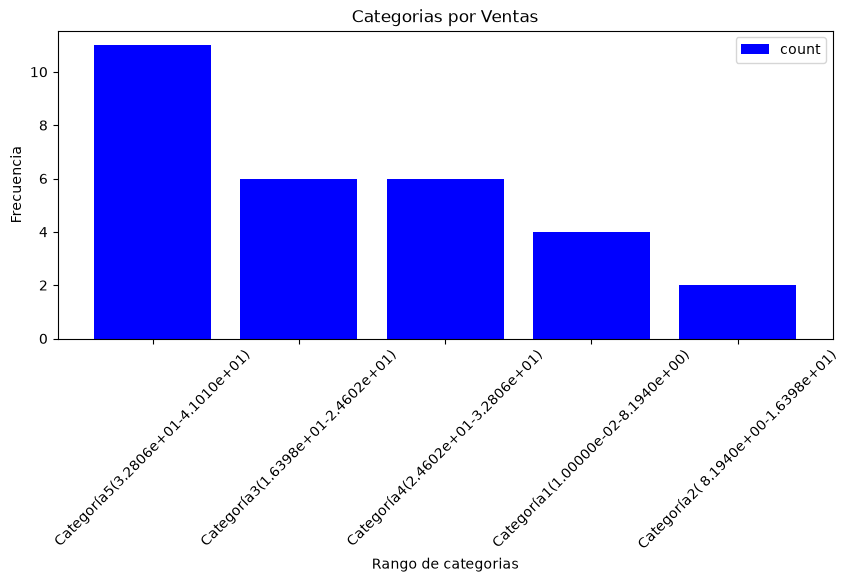

In [245]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "blue", rot=45)
plt.title('Categorias por Ventas')
plt.xlabel('Rango de categorias')
plt.ylabel('Frecuencia')

**Conversion**

In [248]:
#Calculamos el numero total de la población "n"
df['Conversion ']. info()
n=29

<class 'pandas.Series'>
RangeIndex: 29 entries, 0 to 28
Series name: Conversion 
Non-Null Count  Dtype  
--------------  -----  
29 non-null     float64
dtypes: float64(1)
memory usage: 364.0 bytes


In [249]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max=df['Conversion '].max()
Min=df['Conversion '].min()
Limites= [Min, Max]
Limites

[np.float64(0.0), np.float64(5.9)]

In [250]:
#Calculamos el rango R
R=Max-Min
R

np.float64(5.9)

In [251]:
#Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni= 1+3.32*np.log10(n)
ni

np.float64(5.855161353024534)

In [252]:
#Calculamos el Ancho del Intervalo "i"
i=R/ni
i

np.float64(1.0076579694857264)

In [253]:
#Categorización de variables
#Declaramos 8 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos=np.linspace(-0.01, 5.91, 6)
intervalos

array([-0.01 ,  1.174,  2.358,  3.542,  4.726,  5.91 ])

In [254]:
#Creamos las categorías 
categorias= ["Categoría1(-0.01-1.174)", "Categoría2(1.174-2.358)","Categoría3(2.358-3.542)", "Categoría4(3.542-4.726)",
             "Categoría5(4.726-5.91)"]

In [255]:
#Finalmente creamos las categorías en la columna numérica
df['Conversion ']=pd.cut(x= df['Conversion '], bins=intervalos, labels= categorias)
df['Conversion ']

0     Categoría1(-0.01-1.174)
1     Categoría3(2.358-3.542)
2      Categoría5(4.726-5.91)
3     Categoría3(2.358-3.542)
4     Categoría4(3.542-4.726)
5     Categoría1(-0.01-1.174)
6     Categoría4(3.542-4.726)
7     Categoría3(2.358-3.542)
8     Categoría3(2.358-3.542)
9     Categoría3(2.358-3.542)
10    Categoría2(1.174-2.358)
11    Categoría3(2.358-3.542)
12    Categoría4(3.542-4.726)
13    Categoría4(3.542-4.726)
14    Categoría4(3.542-4.726)
15    Categoría3(2.358-3.542)
16     Categoría5(4.726-5.91)
17     Categoría5(4.726-5.91)
18    Categoría4(3.542-4.726)
19    Categoría4(3.542-4.726)
20     Categoría5(4.726-5.91)
21     Categoría5(4.726-5.91)
22     Categoría5(4.726-5.91)
23    Categoría4(3.542-4.726)
24     Categoría5(4.726-5.91)
25    Categoría4(3.542-4.726)
26    Categoría4(3.542-4.726)
27     Categoría5(4.726-5.91)
28     Categoría5(4.726-5.91)
Name: Conversion , dtype: category
Categories (5, str): ['Categoría1(-0.01-1.174)' < 'Categoría2(1.174-2.358)' < 'Categoría3(2.358

In [256]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = df['Conversion '].value_counts().reset_index()
Tabla_freq

,Conversion,count
0,Categoría4(3.542-4.726),10
1,Categoría5(4.726-5.91),9
2,Categoría3(2.358-3.542),7
3,Categoría1(-0.01-1.174),2
4,Categoría2(1.174-2.358),1


In [257]:
#Ajusto el indice de mi dataframe
Filtro_index= Tabla_freq.set_index('Conversion ')
Filtro_index

,count
Conversion,
Categoría4(3.542-4.726),10
Categoría5(4.726-5.91),9
Categoría3(2.358-3.542),7
Categoría1(-0.01-1.174),2
Categoría2(1.174-2.358),1


Text(0, 0.5, 'Frecuencia')

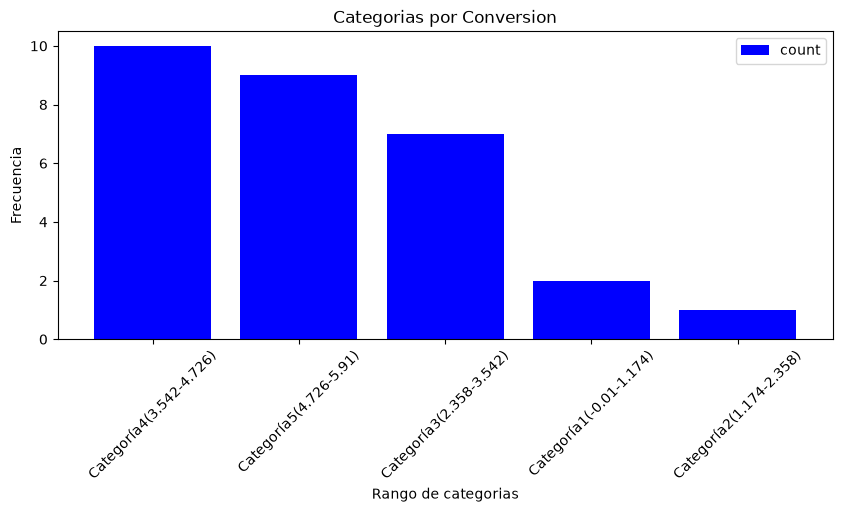

In [258]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "blue", rot=45)
plt.title('Categorias por Conversion')
plt.xlabel('Rango de categorias')
plt.ylabel('Frecuencia')

**Efectividad de Leads**

In [259]:
#Calculamos el numero total de la población "n"
df['Efectividad de Leads']. info()
n=29

<class 'pandas.Series'>
RangeIndex: 29 entries, 0 to 28
Series name: Efectividad de Leads
Non-Null Count  Dtype  
--------------  -----  
29 non-null     float64
dtypes: float64(1)
memory usage: 364.0 bytes


In [260]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max=df['Efectividad de Leads'].max()
Min=df['Efectividad de Leads'].min()
Limites= [Min, Max]
Limites

[np.float64(39.0), np.float64(83.0)]

In [261]:
#Calculamos el rango R
R=Max-Min
R

np.float64(44.0)

In [262]:
#Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni= 1+3.32*np.log10(n)
ni

np.float64(5.855161353024534)

In [263]:
#Calculamos el Ancho del Intervalo "i"
i=R/ni
i

np.float64(7.514737399554569)

In [264]:
#Categorización de variables
#Declaramos 8 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos=np.linspace(38.9, 83.01, 6)
intervalos

array([38.9  , 47.722, 56.544, 65.366, 74.188, 83.01 ])

In [265]:
#Creamos las categorías 
categorias= ["Categoría1(38.9-47.722)", "Categoría2(47.722-56.544)","Categoría3(56.544-65.366)", "Categoría4(65.366-74.188)",
             "Categoría5(74.188-83.01)"]

In [267]:
#Finalmente creamos las categorías en la columna numérica
df['Efectividade de Leads']=pd.cut(x= df['Efectividad de Leads'], bins=intervalos, labels= categorias)
df['Efectividade de Leads']

0     Categoría3(56.544-65.366)
1     Categoría4(65.366-74.188)
2     Categoría4(65.366-74.188)
3     Categoría4(65.366-74.188)
4     Categoría3(56.544-65.366)
5     Categoría3(56.544-65.366)
6     Categoría3(56.544-65.366)
7       Categoría1(38.9-47.722)
8       Categoría1(38.9-47.722)
9       Categoría1(38.9-47.722)
10    Categoría4(65.366-74.188)
11     Categoría5(74.188-83.01)
12    Categoría4(65.366-74.188)
13     Categoría5(74.188-83.01)
14     Categoría5(74.188-83.01)
15     Categoría5(74.188-83.01)
16    Categoría4(65.366-74.188)
17    Categoría3(56.544-65.366)
18    Categoría4(65.366-74.188)
19    Categoría2(47.722-56.544)
20    Categoría3(56.544-65.366)
21    Categoría3(56.544-65.366)
22    Categoría4(65.366-74.188)
23    Categoría2(47.722-56.544)
24      Categoría1(38.9-47.722)
25    Categoría3(56.544-65.366)
26    Categoría2(47.722-56.544)
27    Categoría2(47.722-56.544)
28    Categoría3(56.544-65.366)
Name: Efectividade de Leads, dtype: category
Categories (5, str): ['Cate

In [268]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = df['Efectividade de Leads'].value_counts().reset_index()
Tabla_freq

,Efectividade de Leads,count
0,Categoría3(56.544-65.366),9
1,Categoría4(65.366-74.188),8
2,Categoría1(38.9-47.722),4
3,Categoría2(47.722-56.544),4
4,Categoría5(74.188-83.01),4


In [269]:
#Ajusto el indice de mi dataframe
Filtro_index= Tabla_freq.set_index('Efectividade de Leads')
Filtro_index

,count
Efectividade de Leads,
Categoría3(56.544-65.366),9
Categoría4(65.366-74.188),8
Categoría1(38.9-47.722),4
Categoría2(47.722-56.544),4
Categoría5(74.188-83.01),4


Text(0, 0.5, 'Frecuencia')

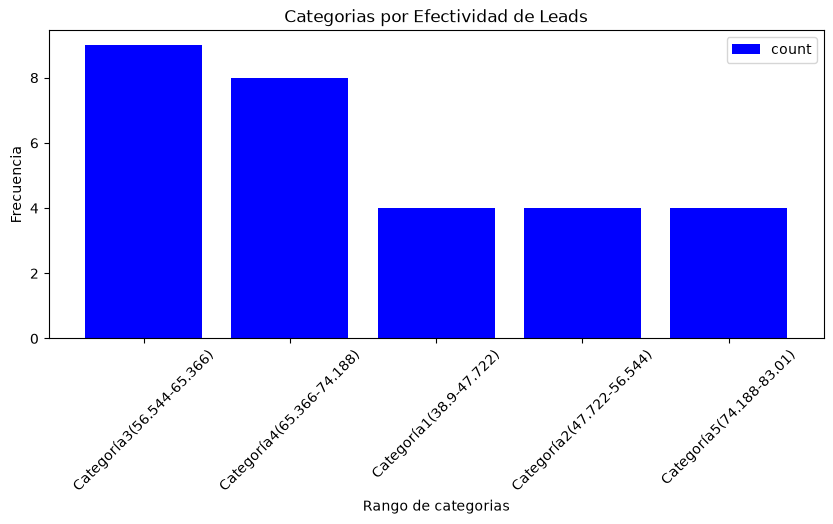

In [270]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "blue", rot=45)
plt.title('Categorias por Efectividad de Leads')
plt.xlabel('Rango de categorias')
plt.ylabel('Frecuencia')